# ECOMMERCE BEHAVIOUR ANALYSIS 
--This project analyze customer behaviour,revenue patterns, and return trends using:
-Pandas
-sql 


In [3]:
import pandas as pd 
import matplotlib.pyplot as pt

In [4]:
df=pd.read_csv(r"C:\Users\Dell\Downloads\ecommerce_behavior.csv")

In [16]:
df.head()

,order_id,customer_id,product_name,category,price,discount,quantity,delivery_days,rating,review_count,stock_left,is_flash_sale,region,payment_type,returned,final_price,order_date,customer_type
0,1,151,Laptop,Tech,4778,34,4,4,4.7,489,21,0,South,UPI,0,3153.48,2023-01-01,repeat_customer
1,2,192,Phone,Tech,1706,11,4,9,2.3,119,30,1,East,Card,1,1518.34,2023-01-02,repeat_customer
2,3,114,Watch,Tech,3028,25,3,4,2.5,442,42,0,North,Card,0,2271.00,2023-01-03,repeat_customer
3,4,171,Shoes,Fashion,1669,18,1,2,4.0,325,9,1,West,COD,0,1368.58,2023-01-04,repeat_customer
4,5,160,Laptop,Tech,1330,44,4,2,2.4,246,11,1,East,COD,0,744.80,2023-01-05,repeat_customer


In [17]:
df.shape

(1000, 18)

In [18]:
df.dtypes

order_id           int64
customer_id        int64
product_name      object
category          object
price              int64
discount           int64
quantity           int64
delivery_days      int64
rating           float64
review_count       int64
stock_left         int64
is_flash_sale      int64
region            object
payment_type      object
returned           int64
final_price      float64
order_date        object
customer_type     object
dtype: object

In [19]:
df.describe()

,order_id,customer_id,price,discount,quantity,delivery_days,rating,review_count,stock_left,is_flash_sale,returned,final_price
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,149.128000,2759.10600,24.678000,2.551000,5.02700,3.009100,257.380000,23.503000,0.479000,0.519000,2072.310040
std,288.819436,29.573505,1246.53897,14.638873,1.120113,2.58901,1.146351,140.003831,14.356047,0.499809,0.499889,1021.016613
min,1.000000,100.000000,506.00000,0.000000,1.000000,1.00000,1.000000,0.000000,0.000000,0.000000,0.000000,283.920000
25%,250.750000,123.000000,1696.00000,12.000000,2.000000,3.00000,2.000000,140.000000,11.000000,0.000000,0.000000,1256.130000
50%,500.500000,150.000000,2736.50000,24.000000,3.000000,5.00000,3.000000,257.000000,23.000000,0.000000,1.000000,2002.530000
75%,750.250000,174.000000,3865.25000,37.250000,4.000000,7.00000,4.000000,376.250000,36.000000,1.000000,1.000000,2787.007500
max,1000.000000,199.000000,4999.00000,49.000000,4.000000,9.00000,5.000000,499.000000,49.000000,1.000000,1.000000,4661.860000


In [20]:
df.columns


Index(['order_id', 'customer_id', 'product_name', 'category', 'price',
       'discount', 'quantity', 'delivery_days', 'rating', 'review_count',
       'stock_left', 'is_flash_sale', 'region', 'payment_type', 'returned',
       'final_price', 'order_date', 'customer_type'],
      dtype='object')

In [21]:
df.columns=df.columns.str.lower()

In [22]:
df.columns=df.columns.str.replace(" ","_")

In [23]:
df.isnull().sum()

order_id         0
customer_id      0
product_name     0
category         0
price            0
discount         0
quantity         0
delivery_days    0
rating           0
review_count     0
stock_left       0
is_flash_sale    0
region           0
payment_type     0
returned         0
final_price      0
order_date       0
customer_type    0
dtype: int64

In [24]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [25]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [26]:
df.dtypes

order_id                  int64
customer_id               int64
product_name             object
category                 object
price                     int64
discount                  int64
quantity                  int64
delivery_days             int64
rating                  float64
review_count              int64
stock_left                int64
is_flash_sale             int64
region                   object
payment_type             object
returned                  int64
final_price             float64
order_date       datetime64[ns]
customer_type            object
dtype: object

In [89]:
df["revenue"]=df["final_price"]*df["quantity"]

In [28]:
df["month"]=df["order_date"].dt.month
df["day_name"]=df["order_date"].dt.day_name()

In [29]:
## REVENUE BY REGION
df.groupby("region")["revenue"].sum()

region
East     1430822.10
North    1463407.12
South    1145937.28
West     1258665.52
Name: revenue, dtype: float64

In [30]:
## REVENUE BY CATEGORY 
df.groupby("category")["revenue"].sum().sort_values(ascending=False)

category
Fashion    2726364.07
Tech       2572467.95
Name: revenue, dtype: float64

In [31]:
## REVENUE BY PRODUCT
df.groupby("product_name")["revenue"].sum().sort_values(ascending=False).head(5)

product_name
Phone         1100748.59
Headphones    1099627.78
Laptop        1086844.15
Shoes         1056961.22
Watch          954650.28
Name: revenue, dtype: float64

In [32]:
## TOP 2 CUSTOMERS
df.groupby("customer_id")["revenue"].sum().sort_values(ascending=False).head(2)

customer_id
100    121778.88
116    114318.32
Name: revenue, dtype: float64

In [33]:
# REVENUE BY CATEGORY AND REGION 
df.groupby(["category","region"])["revenue"].sum().sort_values(ascending=False).unstack()

region,East,North,South,West
category,,,,
Fashion,747086.35,715102.07,618267.91,645907.74
Tech,683735.75,748305.05,527669.37,612757.78


In [34]:
#REVENUE BY PRODUCT AND REGION 
df.groupby(["product_name","region"])["revenue"].sum().sort_values(ascending=False).unstack()

region,East,North,South,West
product_name,,,,
Headphones,300423.10,231978.21,279379.84,287846.63
Laptop,236200.61,286091.75,245936.22,318615.57
Phone,279927.87,384516.52,202044.54,234259.66
Shoes,387949.47,280948.39,211712.02,176351.34
Watch,226321.05,279872.25,206864.66,241592.32


In [35]:
#RELATION BETWEEN QUANTITY AND DISCOUNT 
df["discount_group"]=pd.cut(df["discount"],bins=[0,10,20,30,40,50])
df.groupby("discount_group")["quantity"].sum()

C:\Users\Dell\AppData\Local\Temp\ipykernel_37580\378473810.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("discount_group")["quantity"].sum()


discount_group
(0, 10]     499
(10, 20]    524
(20, 30]    502
(30, 40]    484
(40, 50]    490
Name: quantity, dtype: int64

In [93]:
#FLASH SALE COMPARISON 
df.groupby("is_flash_sale").agg({"revenue":["sum","mean"],"quantity":[
    "sum","mean"],"order_id":"count"})

revenue              quantity           order_id
                      sum         mean      sum      mean    count
is_flash_sale                                                     
0              2829551.39  5431.000749     1337  2.566219      521
1              2469280.63  5155.074384     1214  2.534447      479

In [37]:
df.groupby("product_name").agg({"returned":["sum","mean"]})

returned          
                  sum      mean
product_name                   
Headphones         99  0.480583
Laptop            108  0.537313
Phone             113  0.562189
Shoes             105  0.525000
Watch              94  0.489583

In [38]:
## SALES BY MONTH
df["month_name"] = df["order_date"].dt.strftime("%b")
df.isnull().sum()
df.groupby("month_name")["revenue"].sum()

month_name
Apr    496398.33
Aug    442596.00
Dec    352808.08
Feb    514090.78
Jan    482985.85
Jul    480821.93
Jun    497201.85
Mar    532839.02
May    462463.63
Nov    268757.85
Oct    323583.80
Sep    444284.90
Name: revenue, dtype: float64

In [39]:
## CUSTOMER TYPE 
order_count=df["customer_id"].value_counts()
df["customer_type"]=df["customer_id"].apply(lambda x:"repeat_customer" if order_count[x]>2 else "new")


In [40]:
df.head(100)

,order_id,customer_id,product_name,category,price,discount,quantity,delivery_days,rating,review_count,...,payment_type,returned,final_price,order_date,customer_type,revenue,month,day_name,discount_group,month_name
0,1,151,Laptop,Tech,4778,34,4,4,4.7,489,...,UPI,0,3153.48,2023-01-01,repeat_customer,12613.92,1,Sunday,"(30, 40]",Jan
1,2,192,Phone,Tech,1706,11,4,9,2.3,119,...,Card,1,1518.34,2023-01-02,repeat_customer,6073.36,1,Monday,"(10, 20]",Jan
2,3,114,Watch,Tech,3028,25,3,4,2.5,442,...,Card,0,2271.00,2023-01-03,repeat_customer,6813.00,1,Tuesday,"(20, 30]",Jan
3,4,171,Shoes,Fashion,1669,18,1,2,4.0,325,...,COD,0,1368.58,2023-01-04,repeat_customer,1368.58,1,Wednesday,"(10, 20]",Jan
4,5,160,Laptop,Tech,1330,44,4,2,2.4,246,...,COD,0,744.80,2023-01-05,repeat_customer,2979.20,1,Thursday,"(40, 50]",Jan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,184,Headphones,Tech,4979,48,3,2,1.7,126,...,COD,1,2589.08,2023-04-06,repeat_customer,7767.24,4,Thursday,"(40, 50]",Apr
96,97,179,Shoes,Fashion,2431,15,3,8,3.8,378,...,COD,0,2066.35,2023-04-07,repeat_customer,6199.05,4,Friday,"(10, 20]",Apr
97,98,181,Shoes,Fashion,924,30,3,2,3.1,167,...,Card,0,646.80,2023-04-08,repeat_customer,1940.40,4,Saturday,"(20, 30]",Apr
98,99,152,Laptop,Fashion,1394,41,1,6,3.5,243,...,UPI,1,822.46,2023-04-09,repeat_customer,822.46,4,Sunday,"(40, 50]",Apr


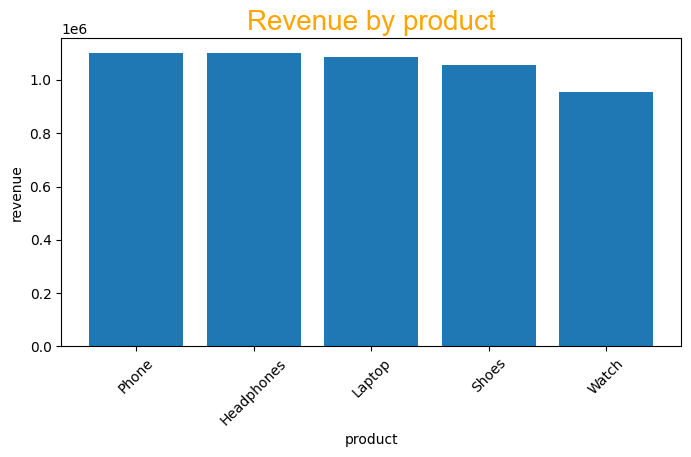

In [96]:
## revenue by product 
rbc=df.groupby("product_name")["revenue"].sum().sort_values(ascending=False)
pt.figure(figsize=(8,4))
pt.bar(rbc.index,rbc.values)
pt.xlabel("product")
pt.ylabel("revenue")
pt.xticks(rotation=45)
pt.title("Revenue by product",color="orange",fontdict={"fontsize":20},fontname="arial")
pt.show()

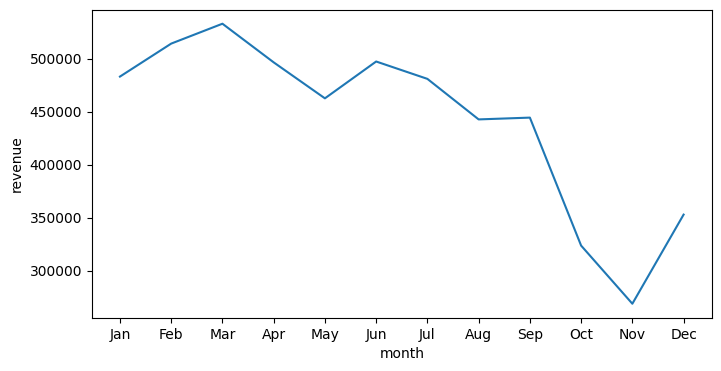

In [101]:
## Monthly trend 
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

monthly = df.groupby("month_name")["revenue"].sum().reindex(month_order)
pt.figure(figsize=(8,4))
pt.plot(monthly.index,monthly.values)
pt.xlabel("month")
pt.ylabel("revenue")
pt.show()

In [87]:
df.revenue.describe()


count     1000.000000
mean      5298.832020
std       3673.909234
min        304.500000
25%       2333.422500
50%       4500.820000
75%       7349.925000
max      18608.240000
Name: revenue, dtype: float64

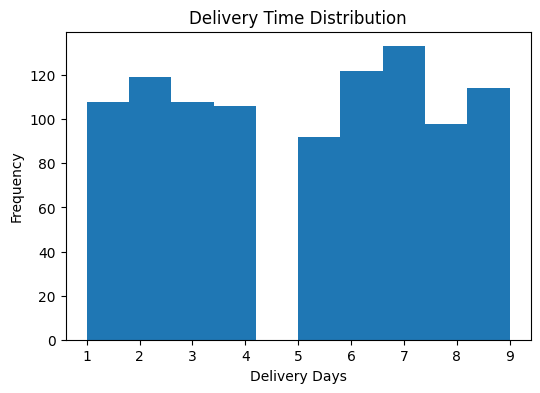

In [103]:
pt.figure(figsize=(6,4))
pt.hist(df["delivery_days"], bins=10)

pt.xlabel("Delivery Days")
pt.ylabel("Frequency")
pt.title("Delivery Time Distribution")
pt.show()


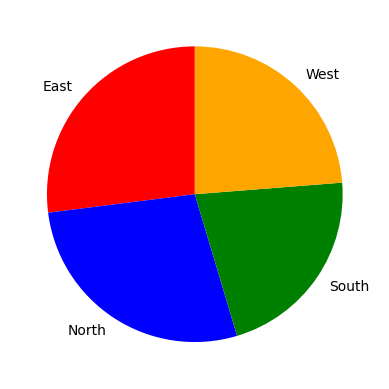

In [113]:
## revenue by region
data=df.groupby("region")["revenue"].sum()
colors = ["red","blue","green","orange"]
pt.pie(data.values,labels=data.index,colors=colors,startangle=90)
pt.show()